In [1]:
# general
import numpy as np
import pandas as pd
import verde as vd
import harmonica as hm
from scipy import interpolate
import xarray as xr
import cmocean
from cmcrameri import cm
import geopandas as gpd

# plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib import animation

# io
from tqdm.auto import tqdm
import os
from pathlib import Path

import sys
sys.path.append('../../src')

import preprocessing
import importlib
importlib.reload(preprocessing)
from preprocessing import *

In [2]:
# bm_path = Path('D:/bedmachine/BedMachineAntarctica-v4.nc')
# antgg_path = Path('D:/AntGG2021_allfiles/AntGG2021_Gravity_disturbance_at-surface.nc')
bm_path = Path('../../raw_data/BedMachineAntarctica-v4.nc')
antgg_path = Path('../../raw_data/antgg.nc')
bedmap_path = Path('G:/bedmap/bedmap3_mod.nc')

# MOA: https://nsidc.org/data/nsidc-0730/versions/1
moa_base = Path('D:/nsidc0730_MEASURES_MOA2014_v01')

# moa coast and grounding line
# moa_coast = gpd.read_file(moa_base/'coastlines/moa2014_coastline_v01.shp')
# moa_gl = gpd.read_file(moa_base/'coastlines/moa2014_grounding_line_v01.shp')
# moa_island = gpd.read_file(moa_base/'coastlines/moa2014_islands_v01.shp')

# glkm = moa_gl.to_crs('+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=km +no_defs +type=crs')
# coastkm = moa_coast.to_crs('+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=km +no_defs +type=crs')
# islandkm = moa_island.to_crs('+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=km +no_defs +type=crs')

In [3]:
region_pig = [-1.75e6, -1.5e6, -0.45e6, -0.2e6]

ds = bedmachine_grid(bm_path, region_pig, 2000)

/blue/emackie/michael.field/conda/envs/gravity/lib/python3.11/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x14c6a7b76340> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/blue/emackie/michael.field/conda/envs/gravity/lib/python3.11/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x14c6a7b76340> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


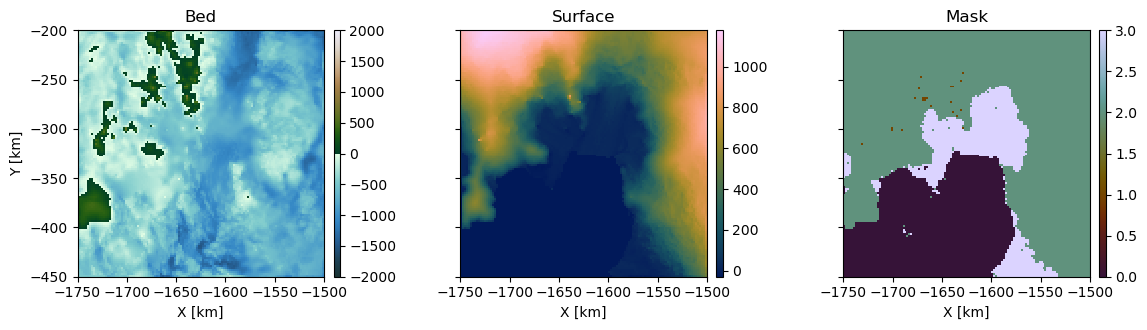

In [4]:
bedmachine_plots(ds, figsize=(14,3.2))

In [5]:
surface, upcon, stdev = antgg_grid_from_bm(ds, max_height=1500)

  0%|          | 0/16 [00:00<?, ?it/s]

/blue/emackie/michael.field/conda/envs/gravity/lib/python3.11/site-packages/verde/model_selection.py:785: FutureWarning: The default scoring will change from R² to negative root mean squared error (RMSE) in Verde 2.0.0. This may change model selection results slightly.
  score = estimator.score(*test_data)
/blue/emackie/michael.field/conda/envs/gravity/lib/python3.11/site-packages/verde/model_selection.py:785: FutureWarning: The default scoring will change from R² to negative root mean squared error (RMSE) in Verde 2.0.0. This may change model selection results slightly.
  score = estimator.score(*test_data)
/blue/emackie/michael.field/conda/envs/gravity/lib/python3.11/site-packages/verde/model_selection.py:785: FutureWarning: The default scoring will change from R² to negative root mean squared error (RMSE) in Verde 2.0.0. This may change model selection results slightly.
  score = estimator.score(*test_data)
/blue/emackie/michael.field/conda/envs/gravity/lib/python3.11/site-packages/

Best score: 0.9774068840668783
Best parameters: {'damping': 1, 'depth': 5000.0}


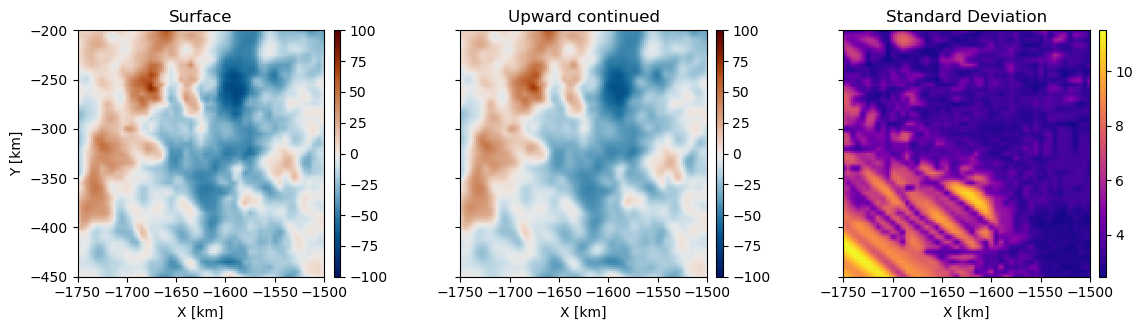

In [6]:
plot_gravity(ds, surface, upcon, stdev, 1500, (14,3.2), 100)

In [7]:
df = pd.read_table(Path('../../raw_data/muto_pig.txt'), names=['PSX', 'PSY', 'LAT', 'LON', 'FAG', 'RES', 'SURF', 'BOT', 'BATHY', 'BASE', 'BATHYERR', 'BASEERR'], skiprows=20, index_col=False, na_values=[-9999])

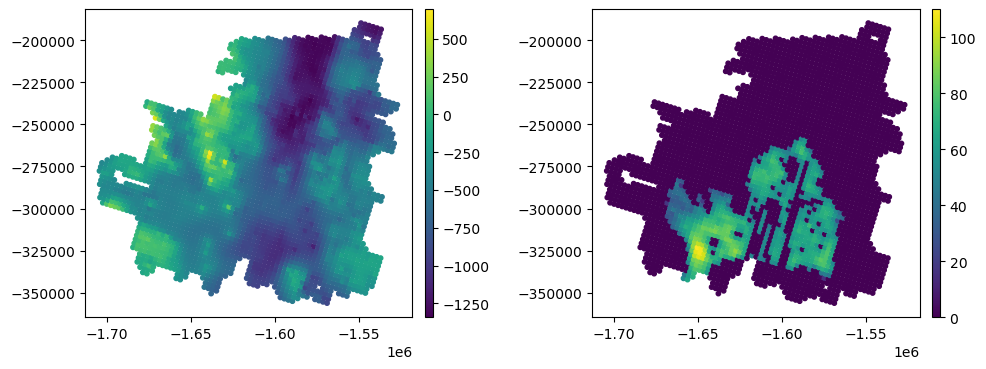

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))
ax = axs[0]
im = ax.scatter(df.PSX, df.PSY, c=-1*df.BATHY, s=10)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.scatter(df.PSX, df.PSY, c=df.BATHYERR, s=10)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

plt.show()

In [9]:
xx, yy = np.meshgrid(ds.x, ds.y)

kn = vd.KNeighbors(k=1)
kn.fit((df.PSX.values, df.PSY.values), df.BATHYERR.values)
preds_err = kn.predict((xx, yy))
bathyerr = preds_err.reshape(xx.shape)

kn.fit((df.PSX.values, df.PSY.values), df.BATHY.values)
preds_bathy = kn.predict((xx, yy))
bathy = preds_bathy.reshape(xx.shape)

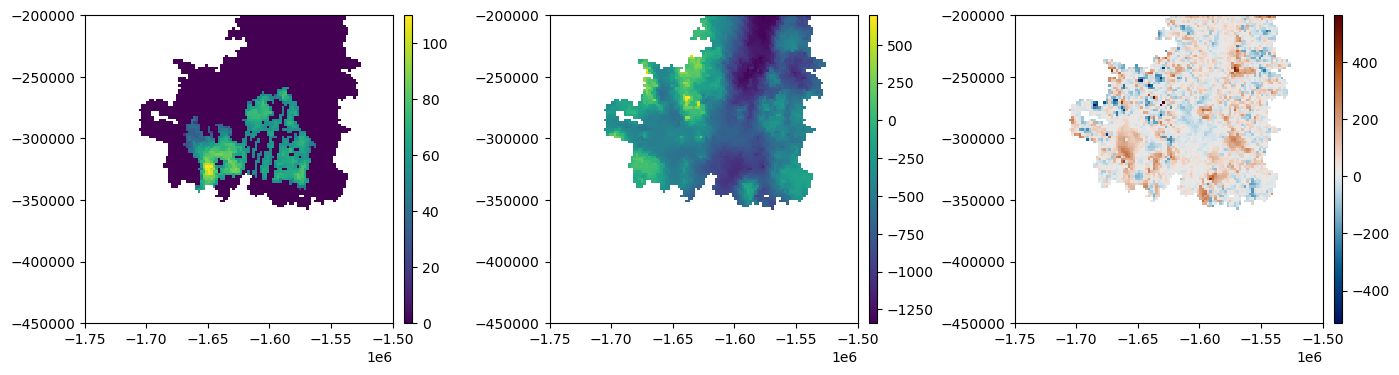

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(17,4))
ax = axs[0]
im = ax.pcolormesh(ds.x, ds.y, bathyerr)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x, ds.y, -1*bathy)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)

ax = axs[2]
im = ax.pcolormesh(ds.x, ds.y, -1*bathy - ds.bed.values, cmap=cm.vik)
ax.axis('scaled')
plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

In [11]:
iceshelf_x = xx[ds.mask!=3]
iceshelf_y = yy[ds.mask!=3]

distance_msk = vd.distance_mask((iceshelf_x, iceshelf_y), maxdist=4000, coordinates=(xx, yy))
distance_msk = ~distance_msk

msk = np.where(distance_msk & (bathyerr==0), True, False)

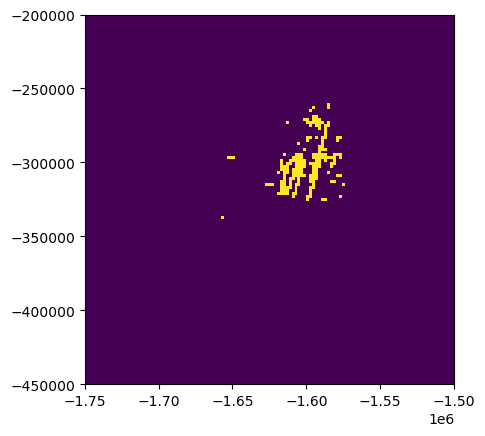

In [12]:
plt.pcolormesh(xx, yy, msk)
plt.axis('scaled')
plt.show()

In [13]:
bed = np.where(msk==True, -1*bathy, ds.bed.values)
cond_msk = (ds.mask.values!=3) | msk | (ds.source.values==10)

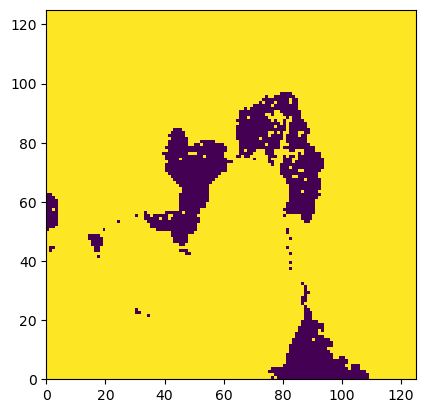

In [14]:
plt.pcolormesh(cond_msk)
plt.axis('scaled')
plt.show()

In [22]:
ds = ds.assign_attrs(res=2000)
xx, yy = np.meshgrid(ds.x.values, ds.y.values)
# inv_msk = np.where(ds.mask==3, True, False)
inv_msk = (~cond_msk) & (yy > -0.375e6)
inv_pad = vd.distance_mask((xx[inv_msk==True], yy[inv_msk]), 20e3, (xx, yy))

bad_bath = np.where((ds.bed.values > (ds.surface.values - ds.thickness.values)) & (ds.mask.values==3), True, False)
thick_adjust = np.where(bad_bath, ds.bed.values + 1, ds.thickness.values)

ds['inv_msk'] = (('y', 'x'), inv_msk)
ds['inv_pad'] = (('y', 'x'), inv_pad)
ds['bed'] = (('y', 'x'), bed)
ds['thickness'] = (('y', 'x'), thick_adjust)

In [23]:
ds['grav_surface'] = (('y', 'x'), surface)
ds['grav_1500'] = (('y', 'x'), upcon)
ds['stdev'] = (('y', 'x'), stdev)
ds.to_netcdf(Path('pig_new.nc'))

In [24]:
xx, yy = np.meshgrid(ds.x.values, ds.y.values)
grav_mask = ds.surface.values < 1500

grav = pd.DataFrame({
    'x' : xx[grav_mask],
    'y' : yy[grav_mask],
    'height' : np.full(xx[grav_mask].size, 1500),
    'faa' : ds.grav_1500.values[grav_mask],
    'inv_msk' : ds.inv_msk.values[grav_mask],
    'inv_pad' : ds.inv_pad.values[grav_mask],
    'stdev' : ds.stdev.values[grav_mask]
})

In [25]:
grav.to_csv('pig_grav_new.csv', index=False)

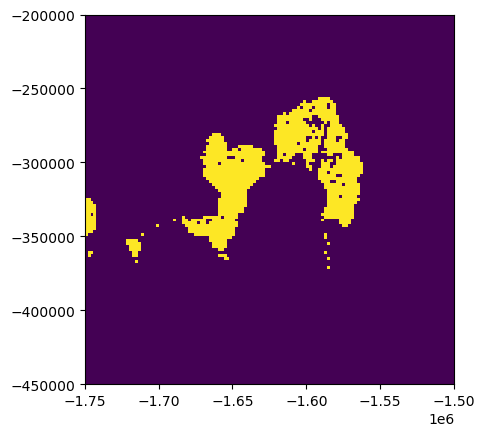

In [26]:
plt.pcolormesh(ds.x, ds.y, ds.inv_msk)
plt.axis('scaled')
plt.show()

In [27]:
grav.shape

(15625, 7)

In [28]:
grav_mskd = grav[grav.inv_pad==True]
grav_mskd.shape

(5069, 7)

In [29]:
bad_bath = np.where((ds.bed.values > (ds.surface.values - ds.thickness.values)) & (ds.mask.values==3), True, False)
np.count_nonzero(bad_bath)

0